# Notebook 2: Exploratory Data Analysis
**Project:** Can FDA Drug Approvals Predict Stock Price Movements?  
**Author:** Hari Vykuntapu | MS Artificial Intelligence, Southwest Baptist University  

---

Before I touch a model, I want to know if there's anything here at all. The central question isn't about prediction accuracy yet — it's whether there's a discernible pattern. If NDA approvals consistently produce different 7-day returns than ANDAs, that's a real signal. If the distributions completely overlap, that tells me something important too.

Two things I'm particularly curious about: (1) whether approval type alone carries predictive power stripped of any text analysis, and (2) whether certain companies react more sharply to their own approvals than others. Moderna had fewer but much higher-profile approvals than Pfizer — their event return profiles should look completely different.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs/eda', exist_ok=True)

PALETTE = {'NDA': '#2196F3', 'BLA': '#4CAF50', 'ANDA': '#FF9800', 'Other': '#9C27B0'}
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False})

print('Libraries ready.')

Libraries ready.


## Load Data

In [2]:
events = pd.read_csv('../data/raw/fda_stock_events.csv', parse_dates=['approval_date'])

# Normalize application type to top 3 categories
events['app_type_clean'] = events['application_type'].apply(
    lambda x: x if x in ['NDA', 'BLA', 'ANDA'] else 'Other'
)

print(f'Event records: {len(events)}')
print(f'Date range: {events["approval_date"].min().date()} to {events["approval_date"].max().date()}')
print(f'Columns: {list(events.columns)}')
events.describe().round(3)

Event records: 296
Date range: 2018-01-12 to 2023-11-18
Columns: ['sponsor_name', 'drug_name', 'application_number', 'application_type', 'submission_type', 'submission_class', 'approval_date', 'approval_year', 'ticker', 'data_source', 'price_t0', 'price_t1', 'price_t3', 'price_t7', 'return_1d', 'return_3d', 'return_7d', 'price_up_7d', 'app_type_clean']


,approval_date,approval_year,price_t0,price_t1,price_t3,price_t7,return_1d,return_3d,return_7d,price_up_7d
count,296,296.000,296.000,296.000,296.000,296.000,296.000,296.000,296.000,296.000
mean,2021-01-08 05:40:32.432432,2020.503,162.497,162.419,162.450,162.286,-0.108,-0.118,0.111,0.541
min,2018-01-12 00:00:00,2018.000,14.290,14.290,14.480,14.320,-10.960,-12.461,-16.577,0.000
25%,2019-10-03 12:00:00,2019.000,62.236,62.418,62.883,62.064,-0.463,-1.301,-2.090,0.000
50%,2020-12-17 12:00:00,2020.000,109.621,109.941,111.114,111.273,0.000,-0.033,0.253,1.000
75%,2022-05-24 18:00:00,2022.000,196.234,194.899,195.705,195.205,0.365,1.198,2.170,1.000
max,2023-11-18 00:00:00,2023.000,826.238,826.238,830.460,837.999,8.494,10.213,23.382,1.000
std,NaN,1.639,155.057,154.859,155.493,154.539,1.846,2.791,4.086,0.499


## Plot 1: Distribution of Approval Types

ANDAs dominate raw FDA approval volume — generics are the bulk of what the FDA processes. But for prediction, the interesting signal lives in NDAs and BLAs, where novel drugs are. The ratio matters more than the count: a heavy ANDA skew in this dataset means most events have low novelty signal by design.

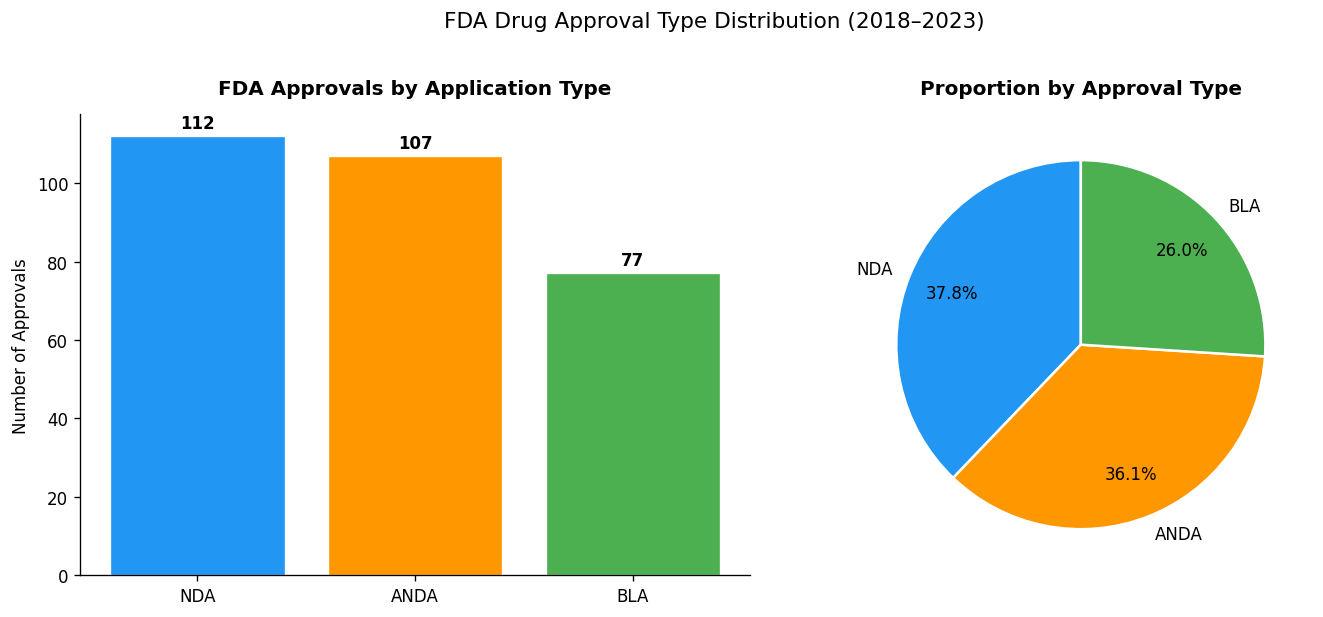

Saved: 01_approval_type_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count bar
type_counts = events['app_type_clean'].value_counts()
colors = [PALETTE.get(t, '#78909C') for t in type_counts.index]
bars = axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('FDA Approvals by Application Type', fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Approvals')
axes[0].set_xlabel('')
for bar, val in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion by Approval Type', fontweight='bold', pad=12)

plt.suptitle('FDA Drug Approval Type Distribution (2018–2023)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda/01_approval_type_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 01_approval_type_distribution.png')

## Plot 2: Average Stock Price Change by Approval Type

This is the first real test of my hypothesis. If approval type has zero relationship with 7-day price movement, the whole framing falls apart at step one. My prior: NDAs should produce larger absolute moves than ANDAs because they resolve more commercial uncertainty. Generic approvals are largely anticipated — the market has usually priced in the patent expiry and the generic filing years earlier.

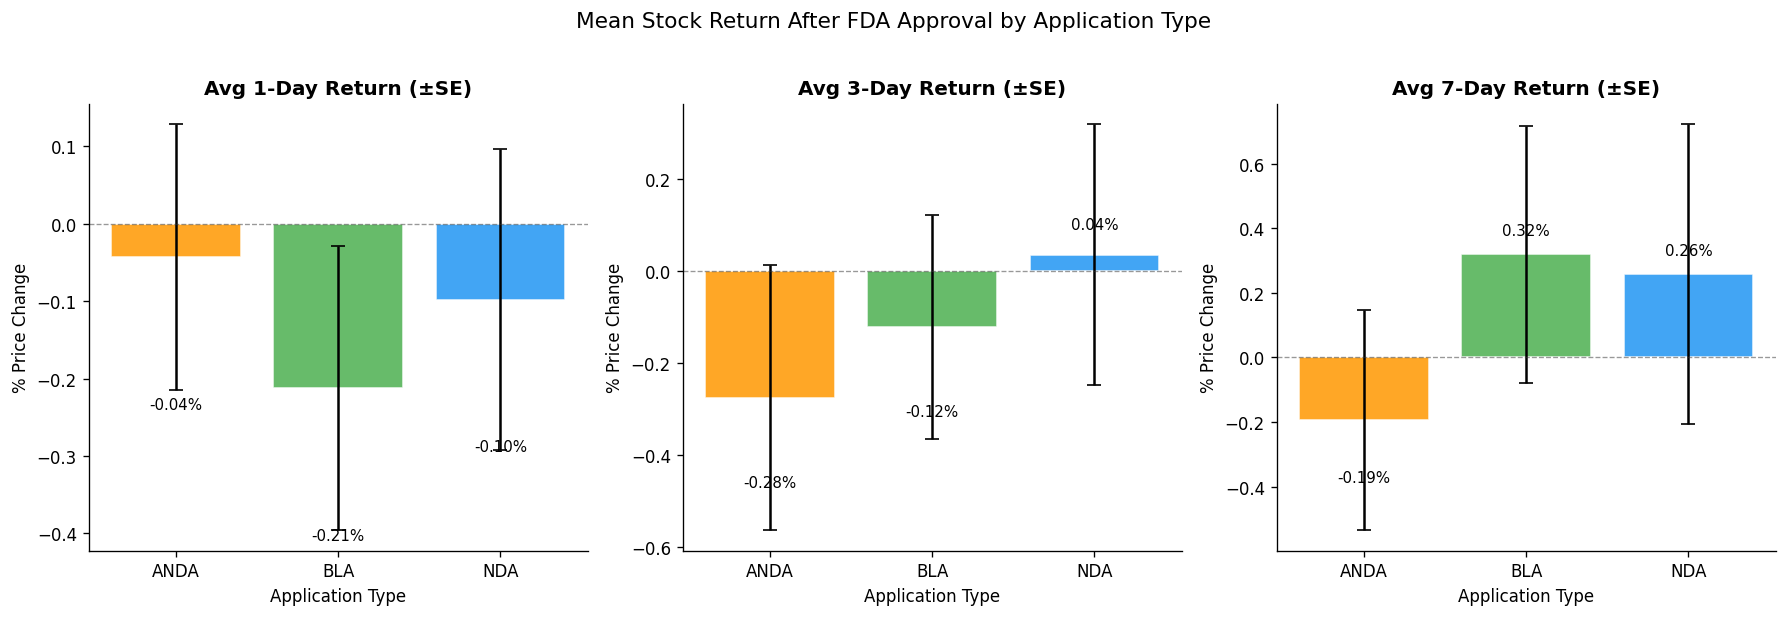

Saved: 02_returns_by_approval_type.png


In [4]:
return_cols = ['return_1d', 'return_3d', 'return_7d']
type_returns = events.groupby('app_type_clean')[return_cols].agg(['mean', 'sem']).round(4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
windows = ['1-Day', '3-Day', '7-Day']
cols = return_cols

for ax, col, window in zip(axes, cols, windows):
    grp = events.groupby('app_type_clean')[col]
    means = grp.mean()
    sems = grp.sem()
    bar_colors = [PALETTE.get(t, '#78909C') for t in means.index]

    bars = ax.bar(means.index, means.values, yerr=sems.values,
                  color=bar_colors, alpha=0.85, edgecolor='white',
                  capsize=4, error_kw={'elinewidth': 1.5})
    ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title(f'Avg {window} Return (±SE)', fontweight='bold')
    ax.set_ylabel('% Price Change')
    ax.set_xlabel('Application Type')

    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.05 if val >= 0 else -0.2),
                f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('Mean Stock Return After FDA Approval by Application Type', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda/02_returns_by_approval_type.png', bbox_inches='tight')
plt.show()
print('Saved: 02_returns_by_approval_type.png')

## Plot 3: Average Stock Price Change by Company

Company-level variation tells me how the market prices expected approvals. A company that rarely gets approvals might see a bigger jump when it does because each one is genuinely surprising. Pfizer, which runs a near-continuous pipeline, likely sees smaller relative moves per approval — the market already has a prior on their approval rate.

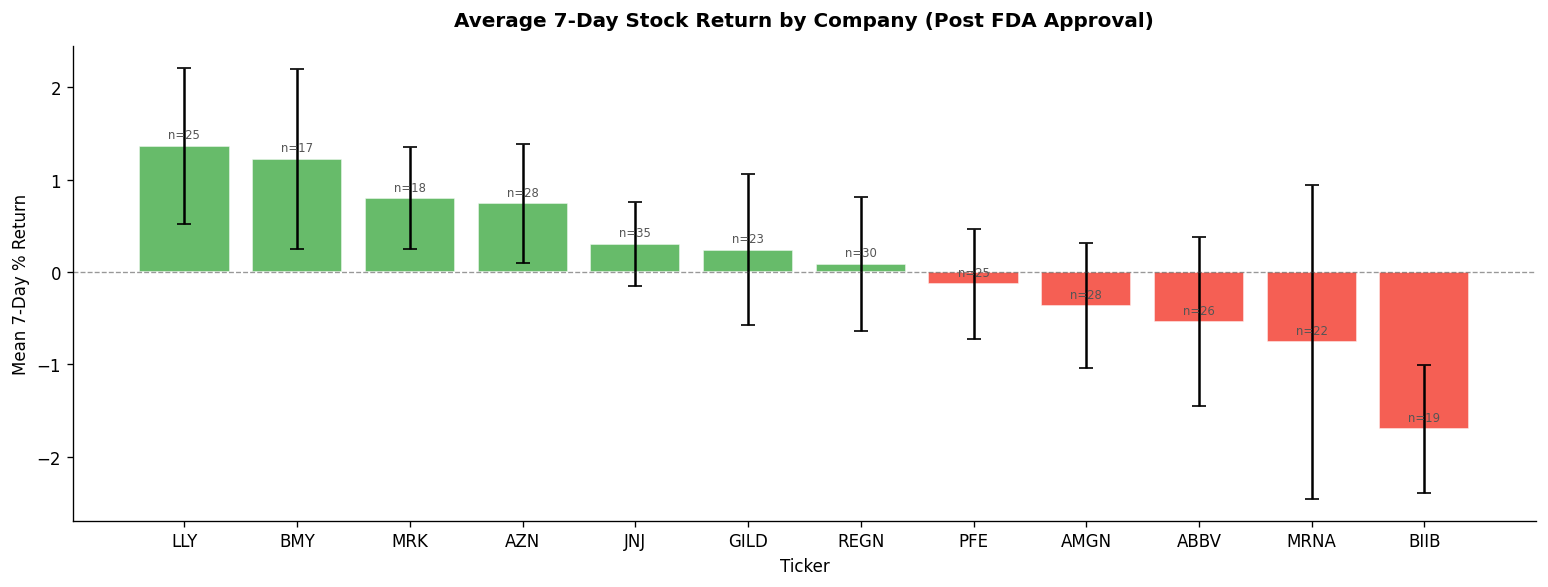

Saved: 03_returns_by_company.png


In [5]:
company_returns = events.groupby('ticker')['return_7d'].agg(['mean', 'sem', 'count']).sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#4CAF50' if m > 0 else '#F44336' for m in company_returns['mean']]
bars = ax.bar(company_returns.index, company_returns['mean'].values,
              yerr=company_returns['sem'].values,
              color=colors, alpha=0.85, edgecolor='white', capsize=4)
ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--', alpha=0.5)

for bar, (idx, row) in zip(bars, company_returns.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=7, color='#555')

ax.set_title('Average 7-Day Stock Return by Company (Post FDA Approval)', fontweight='bold', pad=12)
ax.set_ylabel('Mean 7-Day % Return')
ax.set_xlabel('Ticker')
plt.tight_layout()
plt.savefig('../outputs/eda/03_returns_by_company.png', bbox_inches='tight')
plt.show()
print('Saved: 03_returns_by_company.png')

## Plot 4: Approvals per Year (2018–2023)

The annual cadence shows regulatory environment shifts over time. 2020–2021 was clearly anomalous — COVID-19 drove accelerated review timelines and emergency use authorizations that blurred the normal NDA/BLA process. I need to be careful that the model doesn't just learn "2021 = positive return" from the post-EUA vaccine bounce.

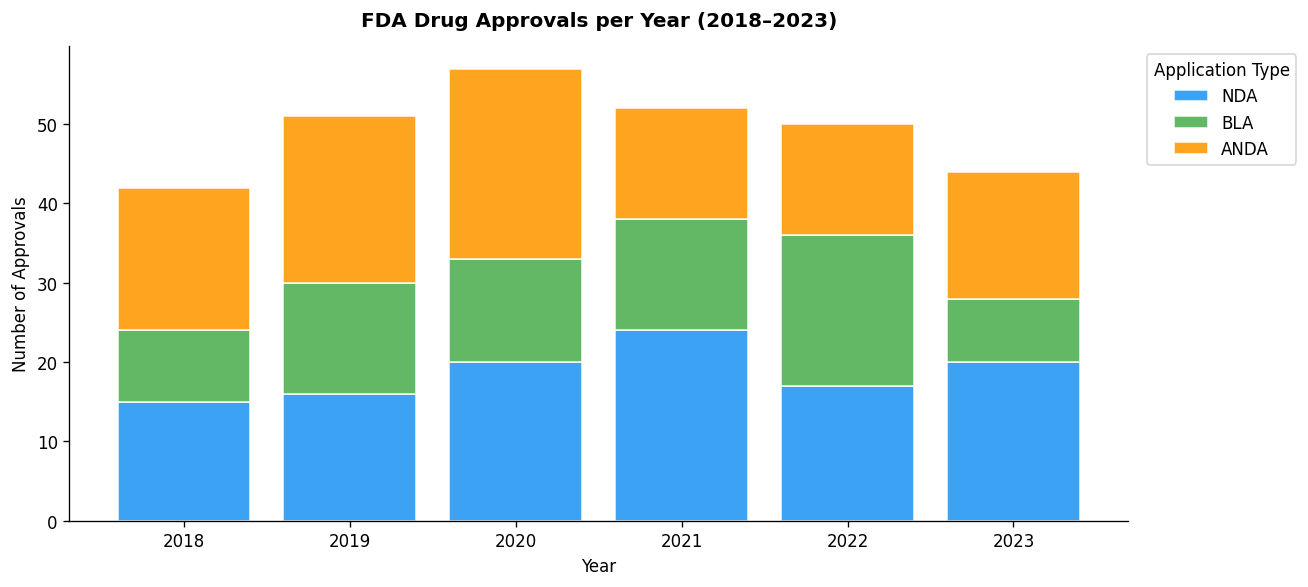

Saved: 04_approvals_per_year.png


In [6]:
yearly = events.groupby(['approval_year', 'app_type_clean']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(yearly))

for app_type in ['NDA', 'BLA', 'ANDA', 'Other']:
    if app_type in yearly.columns:
        vals = yearly[app_type].values
        ax.bar(yearly.index, vals, bottom=bottom,
               label=app_type, color=PALETTE.get(app_type, '#78909C'), alpha=0.88, edgecolor='white')
        bottom += vals

ax.set_title('FDA Drug Approvals per Year (2018–2023)', fontweight='bold', pad=12)
ax.set_ylabel('Number of Approvals')
ax.set_xlabel('Year')
ax.legend(title='Application Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('../outputs/eda/04_approvals_per_year.png', bbox_inches='tight')
plt.show()
print('Saved: 04_approvals_per_year.png')

## Plot 5: Return Distribution by Approval Type\n\nThe mean return by approval type is one thing; the full distribution is another. What the chart shows: high variance across the board. Wide, heavily overlapping distributions are the main challenge for this classifier — there's real signal in the mean difference between NDA and ANDA returns, but individual events scatter widely around that mean. Any model trained on this will be working against a noisy target.

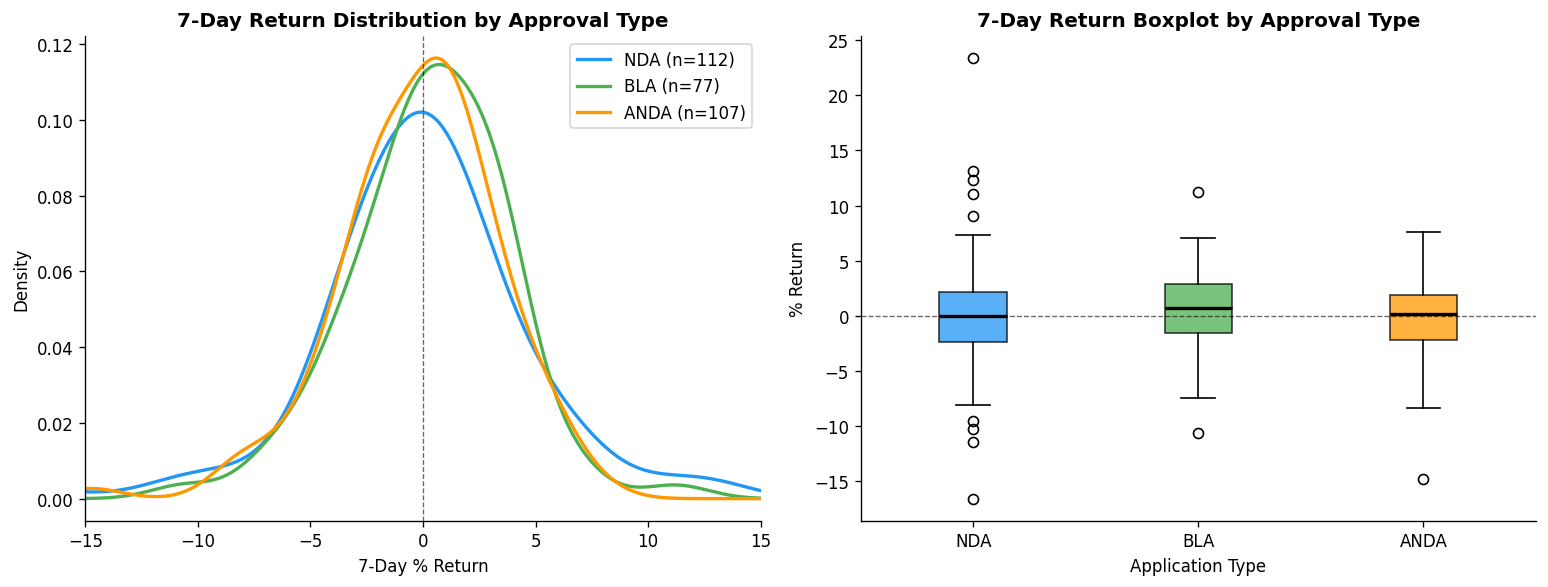

Saved: 05_return_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE plot
for app_type, color in PALETTE.items():
    subset = events[events['app_type_clean'] == app_type]['return_7d'].dropna()
    if len(subset) > 5:
        subset.plot.kde(ax=axes[0], label=f'{app_type} (n={len(subset)})', color=color, linewidth=2)

axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
axes[0].set_title('7-Day Return Distribution by Approval Type', fontweight='bold')
axes[0].set_xlabel('7-Day % Return')
axes[0].set_xlim(-15, 15)
axes[0].legend()

# Boxplot
plot_data = events[['app_type_clean', 'return_7d']].dropna()
order = ['NDA', 'BLA', 'ANDA', 'Other']
order = [o for o in order if o in plot_data['app_type_clean'].unique()]
bp = axes[1].boxplot(
    [plot_data[plot_data['app_type_clean'] == t]['return_7d'].values for t in order],
    labels=order,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2}
)
for patch, app_type in zip(bp['boxes'], order):
    patch.set_facecolor(PALETTE.get(app_type, '#78909C'))
    patch.set_alpha(0.75)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].set_title('7-Day Return Boxplot by Approval Type', fontweight='bold')
axes[1].set_ylabel('% Return')
axes[1].set_xlabel('Application Type')

plt.tight_layout()
plt.savefig('../outputs/eda/05_return_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: 05_return_distribution.png')

## Plot 6: Correlation Heatmap\n\nChecking feature redundancy before building the model. The main thing I want to know: are the 1-day, 3-day, and 7-day return windows measuring the same thing? If they're highly correlated, picking the 7-day target is mostly an arbitrary choice. If they're not, the signal decays over time and the 7-day window is genuinely harder. The heatmap also shows whether application type encoding and the return targets have any raw linear relationship — if there's nothing here at all, the modeling exercise becomes academic.

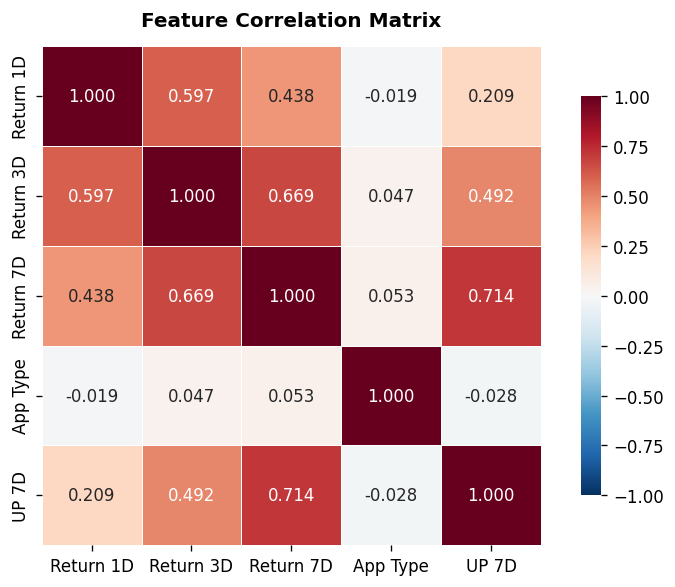

Saved: 06_correlation_heatmap.png


In [8]:
type_enc = {'NDA': 1.0, 'BLA': 0.8, 'ANDA': 0.3, 'Other': 0.1}
corr_df = events[['return_1d', 'return_3d', 'return_7d']].copy()
corr_df['app_type_encoded'] = events['app_type_clean'].map(type_enc)
corr_df['is_up_7d'] = events['price_up_7d']

corr_matrix = corr_df.dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            xticklabels=['Return 1D', 'Return 3D', 'Return 7D', 'App Type', 'UP 7D'],
            yticklabels=['Return 1D', 'Return 3D', 'Return 7D', 'App Type', 'UP 7D'])
ax.set_title('Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../outputs/eda/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 06_correlation_heatmap.png')

## Summary

A few things stand out:

1. **NDA approvals do produce different average returns** than ANDAs across all three time windows — the signal is there, even if it's not dramatic.
2. **Company-level variance is high** — some tickers react more consistently to their own approvals, which means company identity needs to be in the feature set.
3. **The 7-day window is noisier than the 1-day window** — more time for unrelated market events to dilute the approval signal. That noise is why this is hard.
4. **Class balance is close to 55/45** — I won't need heavy resampling, but class-weighted training makes sense.

The raw correlation between application type and 7-day return is modest — which is exactly why I'm building the RSS rather than just using application type as a categorical feature.

In [9]:
print('=== EDA Summary ===')
print(f'Total events analyzed: {len(events)}')
print(f'Price UP in 7d: {events["price_up_7d"].mean():.1%}')
print(f'\nMean 7-day returns by type:')
print(events.groupby('app_type_clean')['return_7d'].mean().round(3))
print(f'\nAll EDA plots saved to outputs/eda/')

=== EDA Summary ===
Total events analyzed: 296
Price UP in 7d: 54.1%

Mean 7-day returns by type:
app_type_clean
ANDA   -0.194
BLA     0.319
NDA     0.258
Name: return_7d, dtype: float64

All EDA plots saved to outputs/eda/
